# **Partitioning Evapotranspiration into Transpiration and Evaporation with Water-Use Efficiency**

Using the coupling between carbon uptake and water loss through stomata to estimate how much of evapotranspiration is transpiration.

## **Learning objectives**

By the end of this tutorial you will be able to:

- Explain why transpiration and photosynthesis are linked and how water-use efficiency expresses that link.
- Compute the underlying water-use efficiency (uWUE) from flux-tower GPP, ET, and vapor pressure deficit.
- Estimate the potential uWUE with quantile regression and derive the transpiration fraction T/ET.
- Check the result against vegetation phenology and discuss where the method is expected to fail.

**Before you start:** Notebook 01. Quantile regression uses `statsmodels`.

## **Why carbon can tell us about water**

Plants open their stomata to take in CO$_2$ for photosynthesis and lose water at the same time. Gross primary productivity
(GPP) and transpiration ($T$) therefore rise and fall together. Soil evaporation ($E$) does not depend on stomata.
Evapotranspiration measured by an eddy-covariance tower is the sum, $ET = T + E$, and we want to split it.

Zhou et al. (2014, 2016) showed that the ratio

$$ uWUE = \frac{GPP \cdot \sqrt{VPD}}{ET} \qquad (1) $$

(the *underlying water-use efficiency*) is nearly constant for a given ecosystem when $ET$ is all transpiration. On days
with soil evaporation, $ET$ is larger than $T$ and the *apparent* uWUE is lower. So:

$$ \frac{T}{ET} = \frac{uWUE_{a}}{uWUE_{p}} \qquad (2) $$

where $uWUE_a$ is computed from the daily data (Eq. 1) and $uWUE_p$, the *potential* uWUE, is the upper envelope of the
$GPP\sqrt{VPD}$ versus $ET$ cloud, estimated with a 95th-percentile quantile regression through the origin.

The method needs only standard flux-tower outputs. Its main assumptions are that $uWUE_p$ is constant in time and that the
upper envelope really corresponds to $T = ET$. In grazed or disturbed systems those assumptions can break, and the
partitioning becomes deficient (Raghav et al., 2022).

**Site used in this tutorial:** US-Var (Vaira Ranch, California), an AmeriFlux grassland site with a Mediterranean climate: wet, mild winters and dry, hot summers. The daily file `daily_data_UA-Var_2000_2021.csv` contains gap-filled fluxes (LE, H, G), net radiation, meteorology, LAI, fPAR, GPP, and soil moisture (`theta_2`) for 2000-2021. Flux units are W m$^{-2}$ (daily means).

`GPP_NT_VUT_REF` is the nighttime-partitioned GPP (gC m$^{-2}$ day$^{-1}$); `VPD_F` is in hPa.

## **Setup: packages and data**

The cell below loads the packages we need and defines a small helper that finds the sample data. If you are running inside the cloned repository it uses the local `sample_data/` folder; on Google Colab it downloads the files from GitHub.

In [1]:
import os, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['figure.dpi'] = 100

BASE = "https://raw.githubusercontent.com/praghav444/CEE491-591-Process-Hydrology-Tutorials/main/sample_data/"

def get_data(fname):
    """Return a local path to a sample data file, downloading it from GitHub if needed."""
    for local in [os.path.join('..', '..', 'sample_data', fname), os.path.join('sample_data', fname)]:
        if os.path.exists(local):
            return local
    os.makedirs('sample_data', exist_ok=True)
    out = os.path.join('sample_data', fname)
    urllib.request.urlretrieve(BASE + fname, out)
    return out

files = ['daily_data_UA-Var_2000_2021.csv']
paths = {f: get_data(f) for f in files}
paths

{'daily_data_UA-Var_2000_2021.csv': '..\\..\\sample_data\\daily_data_UA-Var_2000_2021.csv'}

In [2]:
df = pd.read_csv(paths['daily_data_UA-Var_2000_2021.csv'])
df['Date'] = pd.to_datetime(df['DateTime']); df = df.set_index('Date').drop(columns='DateTime')
df = df.rename(columns={'LE_F_MDS': 'LE', 'TA_F': 'TA', 'VPD_F': 'VPD_hPa', 'GPP_NT_VUT_REF': 'GPP'})
df['VPD'] = df['VPD_hPa'] / 10.0                                  # kPa
lam = 2.501 - 0.002361 * df['TA']                                  # MJ/kg
df['ET'] = df['LE'] * 86400 / (lam * 1e6)                          # mm/day
df['GPP'] = df['GPP'].clip(lower=0)
df['x'] = df['GPP'] * np.sqrt(df['VPD'])                           # gC m-2 d-1 kPa^0.5
use = (df['ET'] > 0.3) & (df['GPP'] > 0.5) & (df['VPD'] > 0.1)
print(f'{use.sum()} usable days')
df.loc[use, ['ET', 'GPP', 'VPD', 'x']].describe().round(2)

3971 usable days


,ET,GPP,VPD,x
count,3971.00,3971.00,3971.00,3971.00
mean,1.41,3.76,0.62,2.87
std,0.89,2.67,0.49,2.37
min,0.30,0.50,0.10,0.19
25%,0.69,1.59,0.29,0.95
50%,1.11,2.93,0.47,2.08
75%,1.99,5.55,0.78,4.19
max,4.44,12.66,3.88,14.29


## **Step 1: The GPP$\sqrt{VPD}$ versus ET cloud and its upper envelope**

Potential uWUE (95th quantile slope) = 3.38 gC kPa^0.5 / kg H2O
Mean slope (OLS) = 2.10


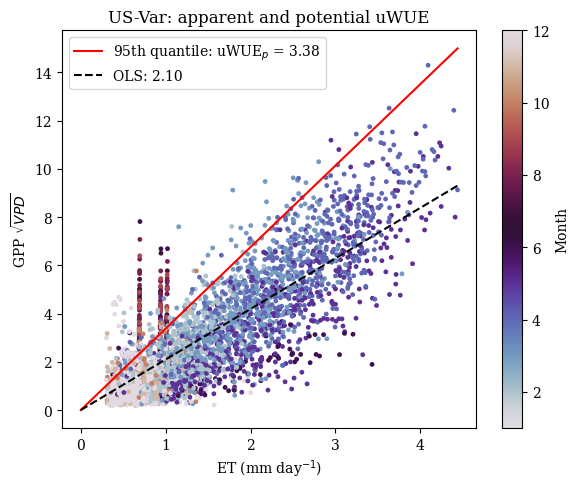

In [3]:
X = df.loc[use, 'ET'].values.reshape(-1, 1)     # regression through the origin: no constant
y = df.loc[use, 'x'].values
q95 = sm.QuantReg(y, X).fit(q=0.95)
uWUE_p = float(q95.params[0])
ols = sm.OLS(y, X).fit(); uWUE_mean = float(ols.params[0])
print(f'Potential uWUE (95th quantile slope) = {uWUE_p:.2f} gC kPa^0.5 / kg H2O')
print(f'Mean slope (OLS) = {uWUE_mean:.2f}')

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(df.loc[use, 'ET'], df.loc[use, 'x'], c=df.loc[use].index.month, cmap='twilight', s=6)
et_line = np.linspace(0, df.loc[use, 'ET'].max(), 10)
ax.plot(et_line, uWUE_p * et_line, 'r-', label=f'95th quantile: uWUE$_p$ = {uWUE_p:.2f}')
ax.plot(et_line, uWUE_mean * et_line, 'k--', label=f'OLS: {uWUE_mean:.2f}')
ax.set_xlabel('ET (mm day$^{-1}$)'); ax.set_ylabel('GPP $\\sqrt{VPD}$'); ax.legend(); plt.colorbar(sc, label='Month')
ax.set_title('US-Var: apparent and potential uWUE'); plt.tight_layout()

## **Step 2: Transpiration fraction**

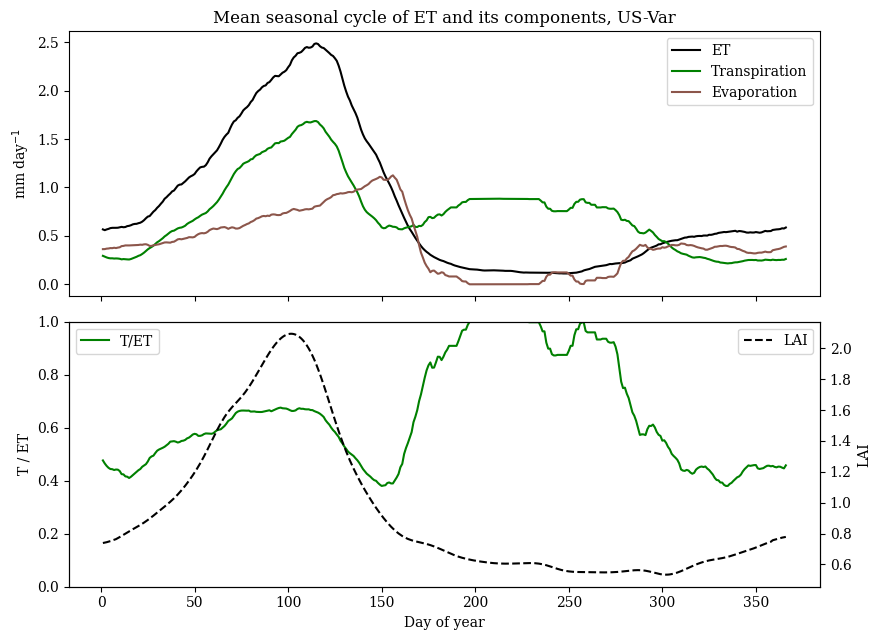

In [4]:
df['uWUE_a'] = np.where(use, df['x'] / df['ET'], np.nan)
df['T_ET'] = (df['uWUE_a'] / uWUE_p).clip(0, 1)
df['T'] = df['T_ET'] * df['ET']; df['E'] = df['ET'] - df['T']

clim = df[['T_ET', 'ET', 'T', 'E', 'LAI', 'theta_2']].groupby(df.index.dayofyear).mean().rolling(15, center=True, min_periods=1).mean()
fig, axs = plt.subplots(2, 1, figsize=(9, 6.5), sharex=True)
axs[0].plot(clim.index, clim['ET'], 'k', label='ET'); axs[0].plot(clim.index, clim['T'], 'g', label='Transpiration')
axs[0].plot(clim.index, clim['E'], 'tab:brown', label='Evaporation'); axs[0].set_ylabel('mm day$^{-1}$'); axs[0].legend()
axs[0].set_title('Mean seasonal cycle of ET and its components, US-Var')
axs[1].plot(clim.index, clim['T_ET'], 'g', label='T/ET'); axs[1].set_ylabel('T / ET'); axs[1].set_ylim(0, 1)
ax2 = axs[1].twinx(); ax2.plot(clim.index, clim['LAI'], 'k--', label='LAI'); ax2.set_ylabel('LAI')
axs[1].set_xlabel('Day of year'); axs[1].legend(loc='upper left'); ax2.legend(loc='upper right'); plt.tight_layout()

**What to notice.** T/ET follows the green-up of the grass. It is low right after the first winter rains, when the soil is
wet but the canopy is small (soil evaporation dominates), rises with LAI in spring, and stays high in the dry summer when
what little ET remains is transpiration from deep-rooted plants and the soil surface is dry.

The annual T/ET at this site is in the range reported for grasslands. Compare it with your expectation before trusting it.

In [5]:
annual = df[['T', 'E', 'ET']].resample('YE').sum()
annual['T/ET'] = annual['T'] / annual['ET']
annual.index = annual.index.year
print(annual.round(2))
print(f"\nMulti-year mean T/ET = {annual['T/ET'].mean():.2f}")

           T       E      ET  T/ET
Date                              
2000  203.21   78.44  303.77  0.67
2001  145.62   98.02  291.38  0.50
2002  135.28   92.92  274.00  0.49
2003  172.44  101.83  329.32  0.52
2004  123.94   95.98  266.83  0.46
2005  197.94  109.67  385.20  0.51
2006  124.95  138.97  315.15  0.40
2007  151.96   80.52  273.46  0.56
2008   78.56  102.96  234.34  0.34
2009  151.69  120.37  322.49  0.47
2010  188.17  113.13  345.31  0.54
2011  139.54  139.59  334.10  0.42
2012  143.74  102.67  289.76  0.50
2013  115.51   79.21  247.46  0.47
2014  154.79   82.81  286.87  0.54
2015  139.89  117.97  301.65  0.46
2016  204.55  103.28  335.57  0.61
2017  122.31  131.13  298.71  0.41
2018  154.79  102.58  300.37  0.52
2019  173.10  118.31  355.76  0.49
2020  147.04  114.36  301.35  0.49
2021  113.61  100.30  272.01  0.42

Multi-year mean T/ET = 0.49


## **Step 3: Where does the method struggle?**

A constant $uWUE_p$ is the key assumption. Check whether the upper envelope is the same in different seasons.

In [6]:
seasons = {'Wet season (Nov-Apr)': [11, 12, 1, 2, 3, 4], 'Dry season (May-Oct)': [5, 6, 7, 8, 9, 10]}
for name, months in seasons.items():
    m = use & df.index.month.isin(months)
    fit = sm.QuantReg(df.loc[m, 'x'].values, df.loc[m, 'ET'].values.reshape(-1, 1)).fit(q=0.95)
    print(f'{name}: uWUE_p = {fit.params[0]:.2f}  (n = {m.sum()})')

Wet season (Nov-Apr): uWUE_p = 3.29  (n = 3101)
Dry season (May-Oct): uWUE_p = 4.23  (n = 870)


If the two values differ by a lot, a single annual $uWUE_p$ is biasing T/ET in one of the seasons. Options are a
seasonal $uWUE_p$, or other partitioning methods (flux variance similarity, isotopes, sap flow scaling) that do not rely
on this assumption. Comparing methods against each other is the only real check, since transpiration is not measured
directly at the tower.

## **Exercises**

**Exercise 1.** Recompute T/ET with a seasonal $uWUE_p$ (Step 3) and compare the annual T/ET with the single-envelope result.

**Exercise 2.** Try the 90th and 99th quantiles instead of the 95th. How sensitive is T/ET to this choice?

**Exercise 3.** Plot daily T/ET against soil moisture `theta_2`. Is there a threshold below which T/ET stops responding? What might that mean physically?

**Exercise 4.** The related method of Zhou et al. (2016) uses GPP$\cdot$VPD$^{0.5}$; earlier work used GPP$\cdot$VPD. Repeat the analysis with the plain product and compare.

## **References**

- Zhou, S., Yu, B., Huang, Y., & Wang, G. (2014). The effect of vapor pressure deficit on water use efficiency at the subdaily time scale. *Geophysical Research Letters*, 41, 5005-5013.
- Zhou, S., Yu, B., Zhang, Y., Huang, Y., & Wang, G. (2016). Partitioning evapotranspiration based on the concept of underlying water use efficiency. *Water Resources Research*, 52, 1160-1175.
- Raghav, P., Wagle, P., Kumar, M., Banerjee, T., & Neel, J. P. S. (2022). Vegetation index-based partitioning of evapotranspiration is deficient in grazed systems. *Water Resources Research*, 58, e2022WR032067.
- Wagle, P., Raghav, P., Kumar, M., & Gunter, A. G. (2022). Influence of water use efficiency parameterizations on flux variance similarity-based partitioning of evapotranspiration. *Agricultural and Forest Meteorology*, 328, 109254.